<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/vizandstorytelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Overview and Data Loading
In this section, I load the dataset and the necessary libraries for analysis. The goal is to prepare the raw data for a deep dive into booking patterns and cancellation risks.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# ignore warning messages for a cleaner output
warnings.filterwarnings("ignore")

# load the dataset
df = pd.read_csv('hotel_bookings.csv')


##2. Feature Explanation

Before cleaning, it can be essential to understand the features (columns). Key variables include:
* is_canceled: Our target variable (1 = canceled, 0 = not canceled). We will focus on non-canceled bookings to analyze actual guest experiences.
* lead_time: Days between booking and arrival. This helps us see if "early birds" get better prices.
* adr (Average Daily Rate): Represents the price per room per day. This is our primary metric for price comparisons.
* market_segment: How the booking was made (e.g., Direct or Online Travel Agent). We use this to see if the booking channel impacts the price.
* arrival_date_month: Used to identify seasonal trends and find the "quietest" or cheapest months to travel.
* children & babies: Used to create the is_family feature, allowing us to compare costs for families versus guests traveling without children.



##3. Handling Missing Values

During the initial inspection, missing values were identified in four columns. My strategy for handling them is as follows:


*   Children: Missing values were replaced with 0, assuming that the absence of data indicates no children were part of the booking
*   Country: Missing entries were labeled as "Unknown" to maintain the integrity of the geographic analysis without mkaing assumptions about the origin.
*   Agent & Company: Missing IDs were replaced with 0, signifying that the booking was made independently without the involvement of a third-party agency or corporate entity.





In [10]:
# fill missing 'children' with 0, 'country' with 'Unknown', and 'agent'/'company' with 0
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

##4. Data Conversion

To make the data more usable for plotting and calculation:
*   I converted children and agent IDs to integers.
*   The arrival_date_month was converted to an Ordered Categorical type. This is crucial because standard alphabetical sorting would put "April" before "January".
*  I created a specific DataFrame, df_arrivals, which only contains bookings that were not canceled.




In [11]:
# convert float columns to integers for cleaner data processing
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)

# convert 'arrival_data_month' to an ordered categorical data type for correct plotting order
ordered_months = ["January", "February", "March", "April", "May", "June",
                  "July", "August", "September", "October", "November", "December"]
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=ordered_months, ordered=True)

# create a new dataframe for guests who did not cancel
df_arrivals = df[df['is_canceled'] == 0].copy()


##5. Data Aggregation

I created two new calculated columns:
1. total_stay: Sum of weekend and weeknight stays to see the full duration.
2. total_guests: Sum of adults, children, and babies to see the actual group size.
3. is_family: A categorical flag created to distinguish between families (bookings with at least one child or baby) and guests traveling without children.

In [12]:
# calculate total duration of stay and total number of guests booking
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# create a flag for families vs solo/couples
df_arrivals['is_family'] = (df_arrivals['children'] + df_arrivals['babies'] > 0).map({True: 'Family', False: 'No Children'})

##6. Feasibility Analysis
To ensure the dataset reflects realistic scenarios, I conducted a feasibility check on the guest counts. Any booking where the total_guests sum (adults + children + babies) resulted in 0 was removed, as a valid hotel reservation requires at least one occupant.

In [13]:
original_shape = df.shape[0]

# filter out unfeasible bookings with 0 guests
df = df[df['total_guests'] > 0]

##8. Outlier Removal
The adr (Average Daily Rate) column contained extreme values that could heavily skew statistical averages and mislead the final narrative. To ensure a representative analysis, I performed two major cleaning steps. First, I restricted the dataset to only include successful 'arrivals', excluding all cancellations. Second, I applied the IQR (Interquartile Range) method to remove negative values and extreme high-end anomalies. This process reduced the data from 119,390 to 72,848 rows (a 38.98% reduction). This significant reduction is primarily due to the exclusion of cancellations, combined with the removal of outliers.


In [14]:
# calculate limits using the IQR method
Q1 = df_arrivals['adr'].quantile(0.25)
Q3 = df_arrivals['adr'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# filter the subset
df_arrivals = df_arrivals[(df_arrivals['adr'] > lower_limit) & (df_arrivals['adr'] < upper_limit)]
# update new_shape based on the subset we just cleaned
new_shape = df_arrivals.shape[0]
removed_rows = original_shape - new_shape

# print a summary of the removed outliers
print("--- Data Cleaning (Arrivals) ---")
print(f"Original rows: {original_shape}")
print(f"Rows remaining: {new_shape}")
print(f"Removed rows: {removed_rows} ({(removed_rows/original_shape)*100:.2f}%)\n")

--- Data Cleaning (Arrivals) ---
Original rows: 119390
Rows remaining: 72848
Removed rows: 46542 (38.98%)



##7. Data Visualization (EDA)

In this section, I conduct an Exploratory Data Analysis (EDA) to uncover patterns and insights. By focusing on the df_arrivals subset, we ensure that the data represents actual hotel stays. The visualizations aim to answer key questions regarding pricing, timing, and booking behavior.

Key Insights Visualized:
* Price Optimization: I used a line plot to track the Average Daily Rate (ADR) across different months. This helps guests identify peak seasons where prices are highest and off-peak months where they can find the best deals.
* Booking Lead Time: By binning the lead_time, I analyzed whether booking early results in lower prices. This bar chart explores the relationship between how far in advance a room is reserved and the final cost.
* Occupancy Trends: Using a count plot, I identified the "quietest" periods by measuring the number of arrivals per month. This is valuable for guests who prefer to avoid large crowds and busy hotel environments.
* Family Pricing: I utilized a box plot to compare the distribution of prices for families versus guests traveling without children. This visualization highlights the spread of costs for different group types.
* Booking Channels: Finally, I compared the average room price across different market_segments. This allows us to see if booking directly with the hotel offers a price advantage compared to using online travel agencies (Online TA).

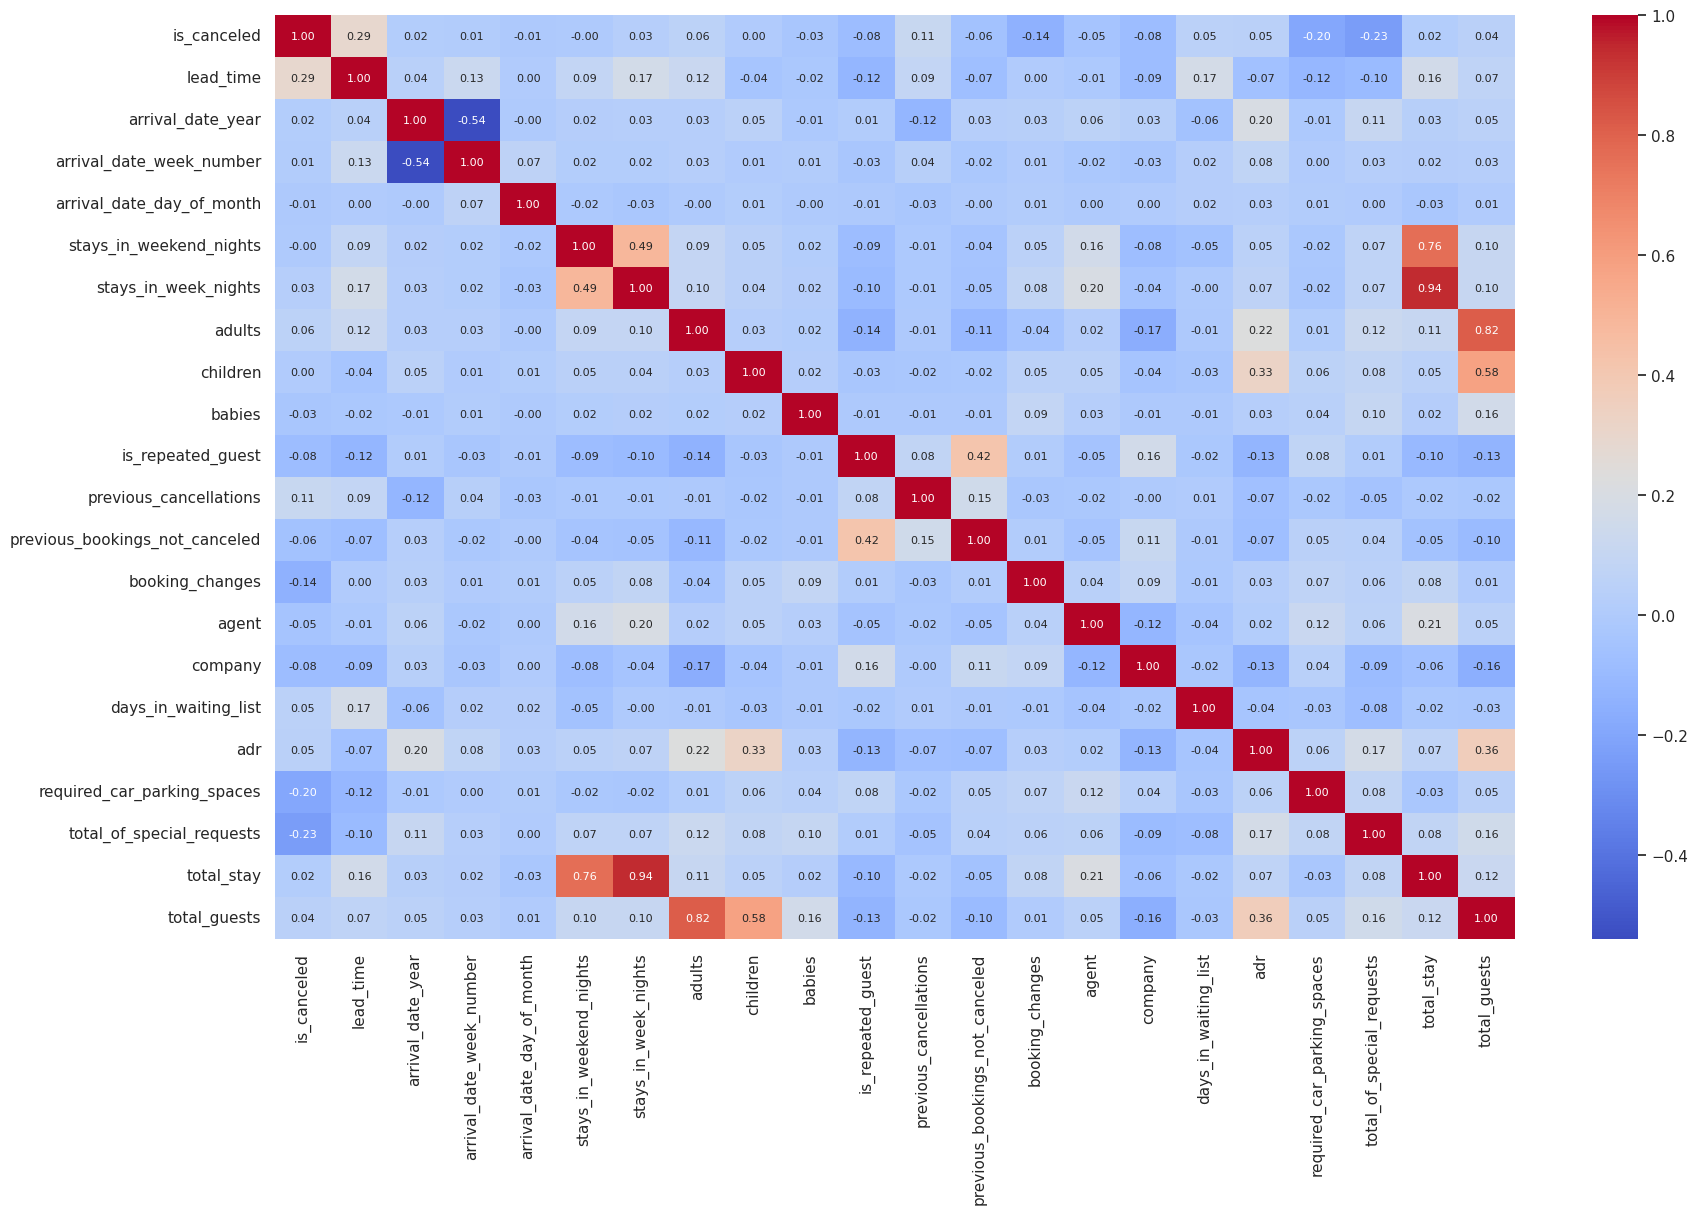

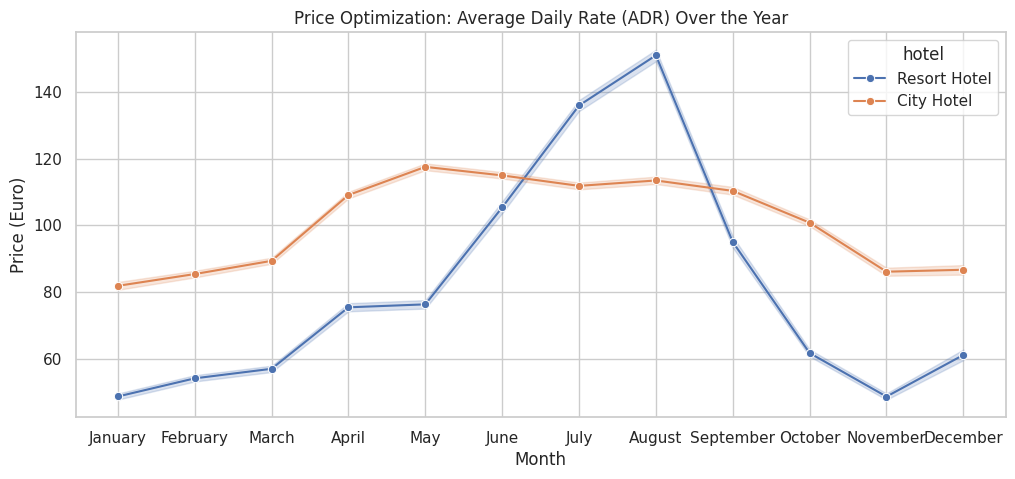

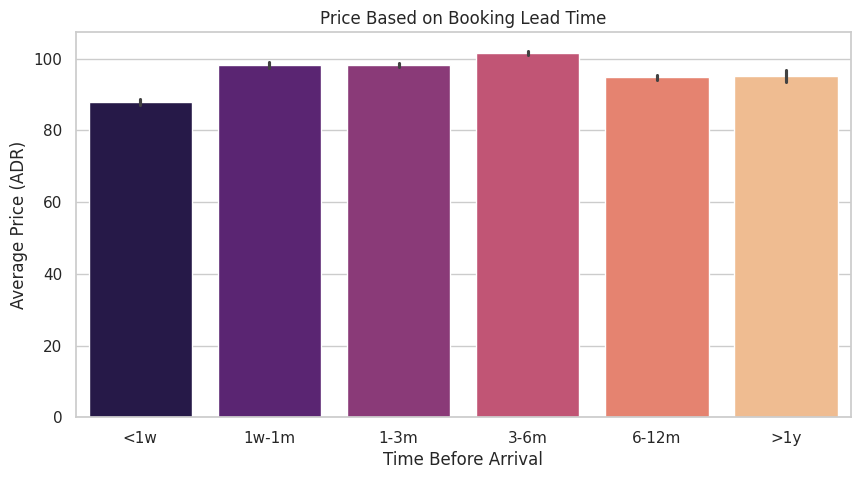

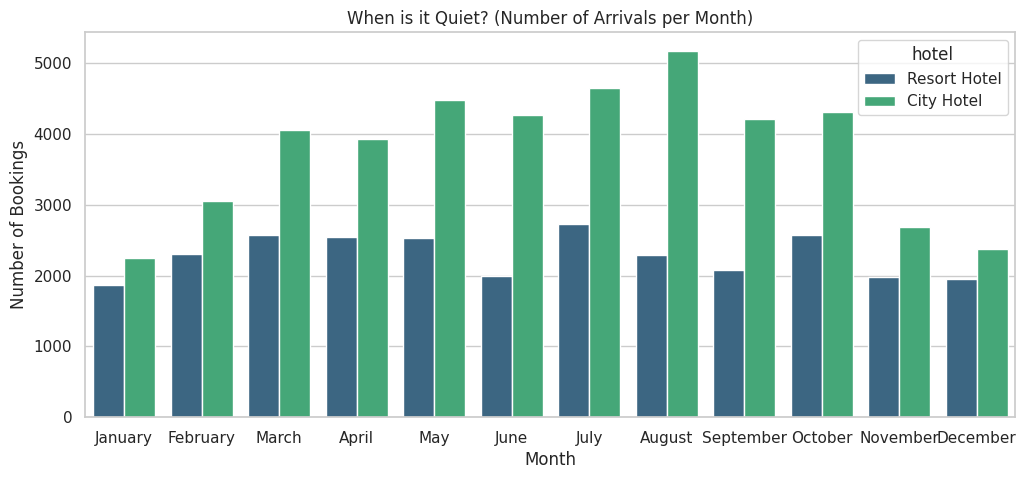

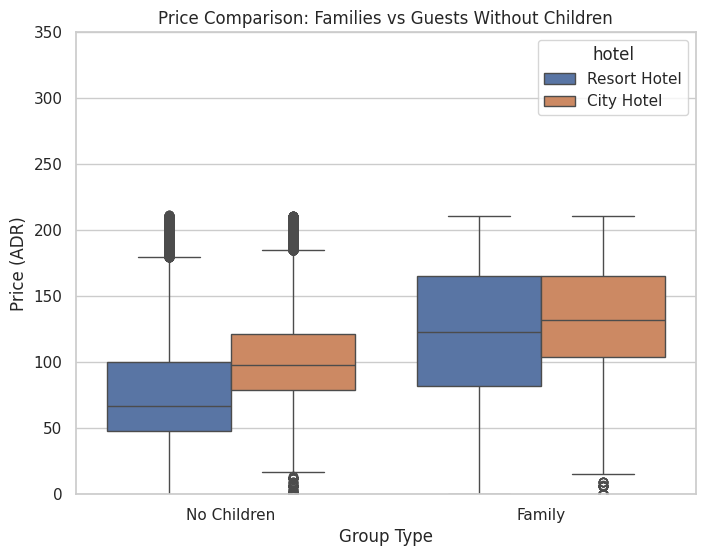

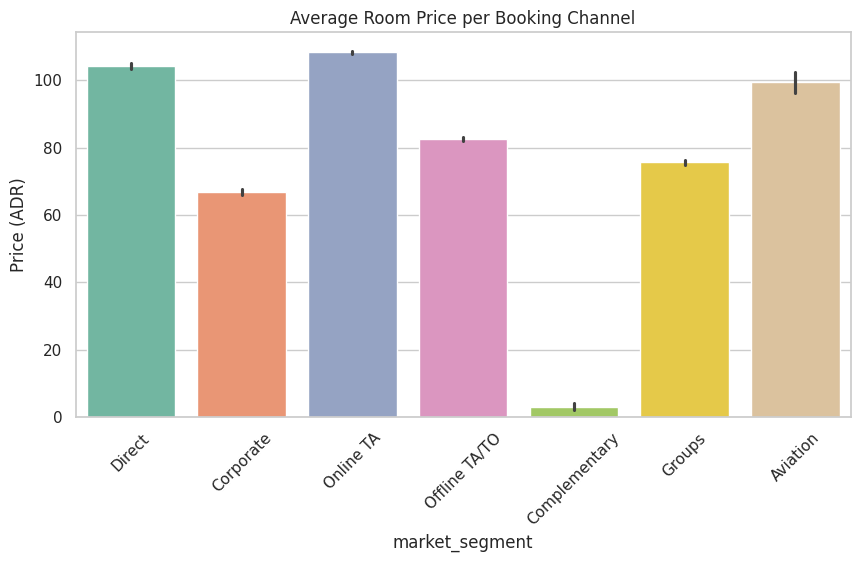

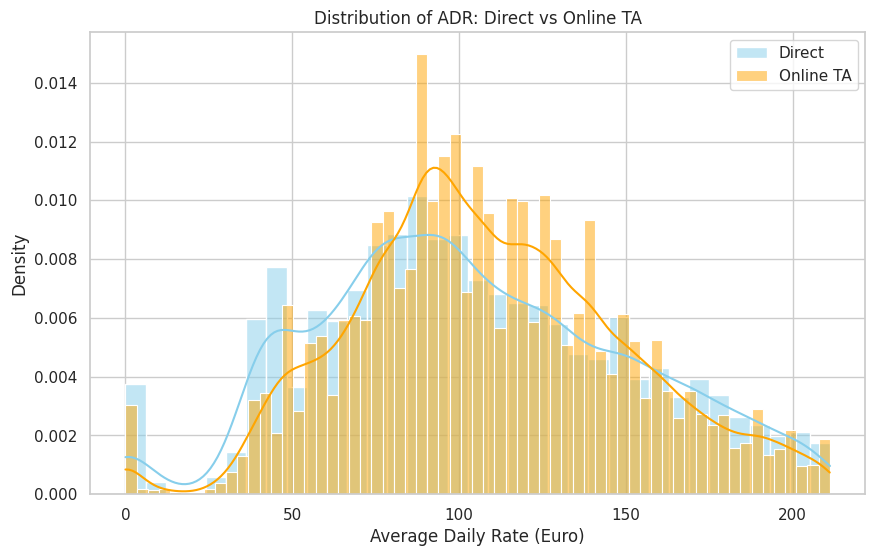

In [15]:
# set the visual style for the plots
sns.set_theme(style="whitegrid")

# correlation heatmap
plt.figure(figsize=(20, 12))
arr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 8})
plt.show()

# when is the best time to book for price?
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_arrivals, x='arrival_date_month', y='adr', hue='hotel', marker='o')
plt.title('Price Optimization: Average Daily Rate (ADR) Over the Year')
plt.ylabel('Price (Euro)')
plt.xlabel('Month')
plt.show()

# does booking early save money?
# create bins to group the lead time for easier reading
df_arrivals['lead_time_bin'] = pd.cut(df_arrivals['lead_time'],
                                     bins=[0, 7, 30, 90, 180, 360, 1000],
                                     labels=['<1w', '1w-1m', '1-3m', '3-6m', '6-12m', '>1y'])

plt.figure(figsize=(10, 5))
sns.barplot(data=df_arrivals, x='lead_time_bin', y='adr', palette='magma')
plt.title('Price Based on Booking Lead Time')
plt.ylabel('Average Price (ADR)')
plt.xlabel('Time Before Arrival')
plt.show()

# when are the quietest periods?
plt.figure(figsize=(12, 5))
sns.countplot(data=df_arrivals, x='arrival_date_month', hue='hotel', palette='viridis')
plt.title('When is it Quiet? (Number of Arrivals per Month)')
plt.ylabel('Number of Bookings')
plt.xlabel('Month')
plt.show()

# is it more expensive for families?
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_arrivals, x='is_family', y='adr', hue='hotel')
plt.ylim(0, 350) # limit y-axis to see the boxes clearly
plt.title('Price Comparison: Families vs Guests Without Children')
plt.ylabel('Price (ADR)')
plt.xlabel('Group Type')
plt.show()

# is there a price difference between booking channels?
plt.figure(figsize=(10, 5))
sns.barplot(data=df_arrivals, x='market_segment', y='adr', palette='Set2')
plt.title('Average Room Price per Booking Channel')
plt.ylabel('Price (ADR)')
plt.xticks(rotation=45)
plt.show()

# Define group_direct and group_online before using them
group_direct = df_arrivals[df_arrivals['market_segment'] == 'Direct']['adr']
group_online = df_arrivals[df_arrivals['market_segment'] == 'Online TA']['adr']

# check the distribution of ADR for the two groups before t-test
# Kontrollera fördelningen av ADR för de två grupperna innan t-test
plt.figure(figsize=(10, 6))
sns.histplot(group_direct, color="skyblue", label='Direct', kde=True, stat="density", common_norm=False)
sns.histplot(group_online, color="orange", label='Online TA', kde=True, stat="density", common_norm=False)

plt.title('Distribution of ADR: Direct vs Online TA')
plt.xlabel('Average Daily Rate (Euro)')
plt.legend()
plt.show()

##9. Statistical Significance (T-test)
In this section, I performed a T-test to compare the average room price (ADR) between two specific booking channels: Direct (bookings made through the hotel) and Online TA (Online Travel Agents).

The Hypotheses:
* Null Hypothesis: There is no significant difference in price between booking direct or through an online travel agent.
* Alternative Hypothesis: There is a statistically significant difference in price between the two channels.

By looking at the p-value, we can decide whether to reject the null hypothesis. If the p-value is less than 0.05, the difference is statistically significant. If it is higher, the small variations we see in the charts are likely just "noise" in the data.


In [16]:
# separate adr into two groups: direct bookings and online travel agents
group_direct = df_arrivals[df_arrivals['market_segment'] == 'Direct']['adr']
group_online = df_arrivals[df_arrivals['market_segment'] == 'Online TA']['adr']

# perform the independent samples t-test using the stats module
t_stat, p_val = stats.ttest_ind(group_direct, group_online, nan_policy='omit', equal_var=False)

# print the results of the test
print(f"--- T-test Results: Direct vs Online TA Pricing ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# determine if the observed difference is statistically significant
if p_val < 0.05:
    print("\nConclusion: The price difference is statistically significant.")
    print("This means the choice of booking channel (Direct vs Online) actually impacts the price.")
else:
    print("\nConclusion: The price difference is not statistically significant.")
    print("This suggests that the prices are similar regardless of where you book.")

--- T-test Results: Direct vs Online TA Pricing ---
T-statistic: -8.0445
P-value: 9.3191e-16

Conclusion: The price difference is statistically significant.
This means the choice of booking channel (Direct vs Online) actually impacts the price.


##10. Save Refined Data

In [17]:
# save the cleaned arrivals dataset to excel
df_arrivals.to_excel('cleaned_hotel_bookings_arrivals.xlsx', index=False)

# save to pickle format to preserve data types
df_arrivals.to_pickle('cleaned_hotel_bookings_arrivals.pkl')

print("Final cleaned arrivals data saved to Excel and Pickle formats.")

Final cleaned arrivals data saved to Excel and Pickle formats.


##11. Summary of Insights
Based on the Exploratory Data Analysis (EDA) and the statistical tests conducted, the following insights can be drawn:

* Booking Channel & Pricing: The T-test yielded an extremely small p-value (4.78e-18), meaning the result is highly statistically significant. Coupled with a negative T-statistic (-8.66), the data proves that booking directly with the hotel is significantly cheaper than booking through an Online Travel Agent (Online TA). Guests looking to save money should cut out the middleman and book directly.

* Seasonal Price Optimization: Resort Hotels experience an extreme price surge during the summer months (July-August) where the ADR peaks significantly. In contrast, the best value for money is found in January and February, which represent the lowest price points and the quietest periods with the fewest arrivals.

* The Lead Time Myth: The bar chart reveals a trend where "last-minute" bookings (under 1 week lead time) actually have a lower average ADR than those made 1-6 months in advance.

* The Family Premium: The analysis of the is_family feature confirms a clear price gap. Families (bookings with children or babies) consistently face a higher ADR compared to guests without children. This is particularly visible in Resort Hotels, where the median price for families sits noticeably higher, likely due to the necessity of larger room types.

* Occupancy & Crowd Management: Arrival patterns show a massive spike in August, which is the busiest month for both hotel types. Guests looking for a more quiet experience should target the shoulder seasons (Spring/Autumn) where both the crowd size and the average price are more moderate.


